# Анализ факторов кредитного риска: Портрет заемщика с просрочкой


<a id='execintro'></a>
## Постановка задачи

На основании ряда данных портрета заемщика в банке определить те, что существенно влияют на вероятность просрочки кредита. Метод - качественный анализ графиков и сводных таблиц.

## Краткие выводы

На основе анализа открытых данных о заемщиках банка выявлены ключевые социально-демографические факторы, влияющие на вероятность возникновения просрочки по кредиту:

1. **Наличие детей** значимо увеличивает вероятность просрочки.

2. **Семейный стаж:** Чем больше у человека опыт в браке, там **ниже** риск возникновения просрочки.

3. **Уровень дохода:** Клиенты с более высоким заявленным доходом имеют меньший риск дефолта.

4. **Цель кредита:** Кредиты на недвижимость (ипотека) показывают самую низкую долю просрочек — **7.2%**, что существенно ниже среднего по портфелю.

## Содержание
- [Постановка задачи](#execintro)
- [Вступление](#intro)
- [Базовый осмотр данных](#view)
- [Предобработка данных](#clean)        
- [Качественное исследование и ответы на вопросы заказчика](#questions)
    - [3.1 Есть ли зависимость между количеством детей и возвратом кредита в срок?](#question1)
    - [3.2 Есть ли зависимость между семейным положением и возвратом кредита в срок?](#question2)
    - [3.3 Есть ли зависимость между уровнем дохода и возвратом кредита в срок?](#question3)
    - [3.4 Как разные цели кредита влияют на его возврат в срок?](#question4)
  - [Общие выводы](#outro)

In [2]:
import pandas as pd
from pathlib import Path

<a id='intro'></a>
## Вступление

Этот проект посвящен поиску и базовой оценке факторов, влияющих на надежность заемщиков, т.е вероятность просрочки человеком выданного ему кредита. **Цель проекта - определить характеристики со значимым влиянием на возможность просрочки кредита, на качественном уровне.** Мы будем оставаться на уровне анализа графиков и сводных таблиц в этом учебном проекте.

Данные для анализа предоставлены анонимным кредитным отделом банка и представляют собой массив характеристик клиентов в сочетании с фактом просрочки кредита или ее отсутствия. Краткое описание столбцов и типов данных:

- **children** — количество детей в семье
- **days_employed** — общий трудовой стаж в днях
- **dob_years** — возраст клиента в годах
- **education** — уровень образования клиента
- **education_id** — идентификатор уровня образования
- **family_status** — семейное положение
- **family_status_id** — идентификатор семейного положения
- **gender** — пол клиента
- **income_type** — тип занятости
- **debt** — имел ли задолженность по возврату кредитов
- **total_income** — ежемесячный доход
- **purpose** — цель получения кредита

План проекта:

1. Очистка данных от артефактов и пропусков.

2. Подготовка переменных, обозначающих гипотетически влияющих на вероятность просрочки групп характеристик заемщика.

3. Предельно базовый анализ влияния выделенных значимых характеристик на вероятность просрочки и ответы на вопросы заказчика.


Заказчик поставил следующие вопросы:

1. Есть ли зависимость между количеством детей и возвратом кредита в срок?

2. Есть ли зависимость между семейным положением и возвратом кредита в срок?

3. Как разные цели кредита влияют на его возврат в срок?

4. Приведите возможные причины появления пропусков в исходных данных

5. Объясните, почему заполнить пропуски медианным значением — хорошее решение для количественных переменных

Эти и только эти вопросы мы будем разбирать в основном теле исследования.

<a id="basic"></a>
## Базовый осмотр данных

Загружаем файл с данными и кратко рассмотрим случайные строки в нем:

In [3]:
data_path = Path.cwd().parent / 'data' / 'data.csv'
try:
    data = pd.read_csv(data_path)
except:
    data = pd.read_csv('https://code.s3.yandex.net/datasets/data.csv')

In [4]:
data.sample(5)

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
1187,0,-190.165786,42,среднее,1,в разводе,3,F,компаньон,0,181913.316618,покупка своего жилья
3594,0,-132.029178,20,среднее,1,Не женат / не замужем,4,F,сотрудник,0,200497.667624,получение образования
11446,2,-211.265213,40,среднее,1,женат / замужем,0,M,компаньон,0,215079.999002,операции со своей недвижимостью
16436,0,-1038.504213,43,Среднее,1,гражданский брак,1,M,сотрудник,0,166996.512492,сыграть свадьбу
16634,1,-135.906159,26,высшее,0,женат / замужем,0,F,сотрудник,0,332758.148561,жилье


Крайне подозрительные данные в столбце **days_employed** - отрицательные значения, не целые числа - кому интересна точность рабочих дней до милионного знака после запятой? Этот столбец первый требует дополнительного рассмотрения. Остальные не показывают каких-то аномалий навскидку, хотя float64 для столбца **total_income** тоже режет глаз. Хорошо бы и иметь словарик для типов семейных отношений и их идентификатора **family_status**. Посмотрим на пустые строки и типы данных:

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


Достатоно много NULL в **days_employed** и **total_income**. Достаточно логичные колонки для пропусков. Разберемся с ними ниже.

<a id='clean'></a>
## Предобработка данных

### Заполнение пропусков в данных и удаление аномалий

Посмотрим на общее число пропусков в переменных.

In [6]:
data.isna().sum()

children               0
days_employed       2174
dob_years              0
education              0
education_id           0
family_status          0
family_status_id       0
gender                 0
income_type            0
debt                   0
total_income        2174
purpose                0
dtype: int64

В **days_employed** и **total_income** есть пропуски.Наиболее логичным для **total_income** будет заменить не указанный доход медианным. Заменим:

In [7]:
data['total_income'] = data.groupby('income_type')['total_income'].transform(
    lambda x: x.fillna(x.median())
)

Далее, посмотрим на **days_employed**. Отрицательные значения совершенно непонятны, но автор данных пояснил, что это просто ошибка и исправлять ее нужно заменяя их на положительные. Возьмем модуль от всего столбца:

In [8]:
data['days_employed'] = data['days_employed'].abs()

Отсалось заполнить пропуски в **days_employed**. Здесь будет грубовато заполнять просто медианным значением. Вместо этого возьмем медианы для каждого типа занятости и заполним ими соответствующие пропуски:

In [9]:
data.groupby('income_type')['days_employed'].agg('median')

income_type
безработный        366413.652744
в декрете            3296.759962
госслужащий          2689.368353
компаньон            1547.382223
пенсионер          365213.306266
предприниматель       520.848083
сотрудник            1574.202821
студент               578.751554
Name: days_employed, dtype: float64

У двух типов (безработные и пенсионеры) получатся аномально большие значения. Исправить такие значения сложно, поэтому мы  оставим их как есть. Тем более этот столбец не понадобится нам для исследования. Исправим теперь собственно **days_employed**:

In [10]:
data['days_employed'] = data.groupby('income_type')['days_employed'].transform(
    lambda x: x.fillna(x.median())
)

Теперь проверим столбец **children** на аномалии.

In [11]:
data['children'].unique()

array([ 1,  0,  3,  2, -1,  4, 20,  5], dtype=int64)

Кто-то родил отрицательное число детей, кто-то 20. Отрицательные точно стоит удалить, 20-и детные скорее всего тоже.

In [12]:
data['children'].value_counts()

children
 0     14149
 1      4818
 2      2055
 3       330
 20       76
-1        47
 4        41
 5         9
Name: count, dtype: int64

Да, 20-ь детей явно аномалия, если 4 и 5 меньше заемщиков имеет. Удаляем:

In [13]:
data = data[(data['children'] != -1) & (data['children'] != 20)]

In [14]:
data['children'].unique()

array([1, 0, 3, 2, 4, 5], dtype=int64)

С пропусками разобрались:

In [15]:
data.isna().sum()

children            0
days_employed       0
dob_years           0
education           0
education_id        0
family_status       0
family_status_id    0
gender              0
income_type         0
debt                0
total_income        0
purpose             0
dtype: int64

Из менее существенных изменений, сделаем **total_income** целочисленным типом.

In [16]:
data['total_income'] = data['total_income'].astype(int)

Двигаясь далее, уберем дубликаты из **education**. Там могут быть скрытые дубликаты, возникающие из-за строчных и прописных букв. ПРиведем все к строчным, а затем удалим все дубликаты со всего файла.

In [17]:
data['education'] = data['education'].str.lower()

In [18]:
data.duplicated().sum()

71

In [19]:
data = data.drop_duplicates()

### Категоризация данных

Для качественного анализа без погружения в детали и регрессии, мы преобразуем **total_income_category** в категориальный столбец:

- 0–30000 — `'E'`;
- 30001–50000 — `'D'`;
- 50001–200000 — `'C'`;
- 200001–1000000 — `'B'`;
- 1000001 и выше — `'A'`.

In [20]:
def categorize_income(income):
    try:
        if 0 <= income <= 30000:
            return 'E'
        elif 30001 <= income <= 50000:
            return 'D'
        elif 50001 <= income <= 200000:
            return 'C'
        elif 200001 <= income <= 1000000:
            return 'B'
        elif income >= 1000001:
            return 'A'
    except:
        pass

In [21]:
data['total_income_category'] = data['total_income'].apply(categorize_income)

Далее, рассмотрим самый пестрый столбец целей кредита **purpose**. Здесь скорее всего будет много похожих целей разными словами.

In [22]:
data['purpose'].unique()

array(['покупка жилья', 'приобретение автомобиля',
       'дополнительное образование', 'сыграть свадьбу',
       'операции с жильем', 'образование', 'на проведение свадьбы',
       'покупка жилья для семьи', 'покупка недвижимости',
       'покупка коммерческой недвижимости', 'покупка жилой недвижимости',
       'строительство собственной недвижимости', 'недвижимость',
       'строительство недвижимости', 'на покупку подержанного автомобиля',
       'на покупку своего автомобиля',
       'операции с коммерческой недвижимостью',
       'строительство жилой недвижимости', 'жилье',
       'операции со своей недвижимостью', 'автомобили',
       'заняться образованием', 'сделка с подержанным автомобилем',
       'получение образования', 'автомобиль', 'свадьба',
       'получение дополнительного образования', 'покупка своего жилья',
       'операции с недвижимостью', 'получение высшего образования',
       'свой автомобиль', 'сделка с автомобилем',
       'профильное образование', 'высшее об

 Это можно перебрать почти вручную. Сделаем стобец **purpose_category** со следующими категориями:

- `'операции с автомобилем'`,
- `'операции с недвижимостью'`,
- `'проведение свадьбы'`,
- `'получение образования'`.

In [23]:
def categorize_purpose(row):
    try:
        if 'автом' in row:
            return 'операции с автомобилем'
        elif 'жил' in row or 'недвиж' in row:
            return 'операции с недвижимостью'
        elif 'свад' in row:
            return 'проведение свадьбы'
        elif 'образов' in row:
            return 'получение образования'
    except:
        return 'нет категории'

In [24]:
data['purpose_category'] = data['purpose'].apply(categorize_purpose)

### Краткие итоги обработки данных

Мы провели быструю обработку данных, а именно:
- были заполнены NULL в столбцах **days_employed** и **total_income** - в первом через медианные значения для каждого вида занятости **income_type**, во втором просто через медианный доход. Было бы логично применить категориальные медианы и для второго случая, но это нарушает требования учебного проекта
- были удалены аномальные значения столбца **children** - 20 детей и -1 ребенок у заемщика. Число таких строк не велико и это явная ошибка, можно удалить. То, что 20 детей - ошибка подтверждается и тем, что таких строк было болье чем заемщиков с 4 и 5 детьми.
- **total_income** был заменен на целочисленный тип. Нет нужды знать доход заемщика до миллионной доли - это тоже явная ошибка, доля может быть только сотой
- Были введены два новых категориальных столбца **total_income_category** и **purpose_category** для последующего анализа

<a id='questions'></a>
### Качественное исследование и ответы на вопросы заказчика

Вооружившись обработанными данными, начнем отвечать на вопросы заказчика:

<a id='question1'></a>
#### Есть ли зависимость между количеством детей и возвратом кредита в срок?

Для начала, посмотрим просто на количество клиентов, количество просрочек и процент случаев невозврата кредита в зависимости от количества детей (последнее - просто средние от переменной debt):

'Данные о просрочках в зависимости от числа детей:'

,total_clients,total_failed_debts,probability_of_failed_debt
children,,,
0,14091,1063,0.075438
1,4808,444,0.092346
2,2052,194,0.094542
3,330,27,0.081818
4,41,4,0.097561
5,9,0,0.000000


'Средняя вероятность просрочки в целом на выборке:'

'0.0812'

<Axes: xlabel='children'>

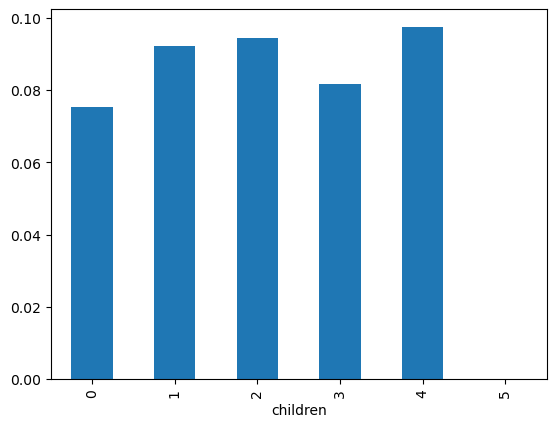

In [25]:
# Выводим сводную таблицу  по переменной дети с количеством клиентов, количеством просрочек и их средней величиной:
display('Данные о просрочках в зависимости от числа детей:')
data_pivot= data.pivot_table(index=['children'], values='debt', aggfunc='count')
data_pivot['total_failed_debts'] = data.pivot_table(index=['children'], values='debt', aggfunc='sum')
data_pivot['probability_of_failed_debt'] = data.pivot_table(index=['children'], values='debt', aggfunc='mean')
data_pivot = data_pivot.rename(columns={'debt': 'total_clients'})
display(data_pivot)
display('Средняя вероятность просрочки в целом на выборке:', "{0:.4f}".format(data['debt'].mean()))
# Выводим график вероятности в зависимости от числа детей:
data_children_suspect = data.groupby('children')['debt'].agg('mean')
data_children_suspect.plot.bar()


**Несколько гипотез:**

1. бездетные реже допускают задолженности по кредитам, чем те что с детьми

2. Вероятность возникновения задолженности растет в зависимости от числа детей

Проверим количество данных в выборке, чтобы понимать, насколько можно доверять данным:

Нет достаточно данных, чтобы реально сравнивать выборки многодетных семей (4, 5 детей) с семьями с 1,2 или 0 детьми. На малом количестве данных в хвостах могут быть статвыбросы, желательно же чтобы количество семей с каждым числом детей было сопоставимо. Можно сравнить выборку бездетных и семей вообще с детьми:

In [26]:
# создаем функцию для нового столбца, указывающего - "есть дети или нет"
def find_children(children):
    try:
        if children == 0:
            return 'без детей'
        elif children > 0:
            return 'с детьми'
    except:
        pass

# применяем функцию и создаем новый столбец
data['is_childless'] = data['children'].apply(find_children)

# с его помощью выводим средние значения по debt - вероятности возникновения просрочки по кредиту
display(data.groupby('is_childless')['debt'].agg('mean'))

is_childless
без детей    0.075438
с детьми     0.092403
Name: debt, dtype: float64

С учетом сопоставимости колчества человек в этих двух категориях - можно сделать (предварительный) вывод, что наличие детей увеличивает вероятность просрочки кредита.

Попробуем все же проверить вторую гипотезу, кое-как разбив выборку на многодетных семей (3 и больше детей).

In [27]:
# решение аналогично предыдущему, 
def many_children(children):
    try:
        if children >= 3:
            return 'многодетные'
        return children
    except:
        pass

# применяем функцию и создаем новый столбец
data['has_many_children'] = data['children'].apply(many_children)

# с его помощью выводим средние значения по debt - вероятности возникновения просрочки по кредиту
display(data.groupby('has_many_children')['debt'].agg('mean'))
display('Средняя вероятность в целом на выборке:', "{0:.4f}".format(data['debt'].mean()))

has_many_children
0              0.075438
1              0.092346
2              0.094542
многодетные    0.081579
Name: debt, dtype: float64

'Средняя вероятность в целом на выборке:'

'0.0812'

Отсюда, утверждать, что с ростом количество детей вероятность просрочки по кредиту растет - нельзя. Из данных, возможно, что многодетные семьи вообще более финансово грамотны, но чтобы это утверждать хотелось бы больше данных в выборке.

**Вывод: Явно заметна закономерность на текущих данных - бездетные люди реже допускают просрочки по кредитам, чем люди с детьми, вплоть 1,7-1,9 пп выше вероятность просрочки у клиентов с 1-2 детьми в сравнении с бездетными. Не обнаружено зависимости роста вероятности просрочки от числа детей. Возможно, многодетные люди меньше допускают просрочки, чем люди с 1-2 детьми (примерно на 1-1,2 пп на текущих данных), но на текущих данных эту гипотезу достоверно не проверить из-за малой выборки числа таких клиентов.**

<a id='question2'></a>
#### Есть ли зависимость между семейным положением и возвратом кредита в срок?

Аналогично предыдущему, сразу проверим количество данных в выборках и средние значения:

In [28]:
# Выводим сводную таблицу с количеством клиентов, количеством просрочек и их средней величиной:
display('Данные о просрочках в зависимости от числа детей:')
data_pivot= data.pivot_table(index=['family_status'], values='debt', aggfunc='count')
data_pivot['total_failed_debts'] = data.pivot_table(index=['family_status'], values='debt', aggfunc='sum')
data_pivot['probability_of_failed_debt'] = data.pivot_table(index=['family_status'], values='debt', aggfunc='mean')
data_pivot = data_pivot.rename(columns={'debt': 'total_clients'})
display(data_pivot)
display('Средняя вероятность просрочки в целом на выборке:', "{0:.4f}".format(data['debt'].mean()))


'Данные о просрочках в зависимости от числа детей:'

,total_clients,total_failed_debts,probability_of_failed_debt
family_status,,,
Не женат / не замужем,2796,273,0.097639
в разводе,1189,84,0.070648
вдовец / вдова,951,63,0.066246
гражданский брак,4134,385,0.093130
женат / замужем,12261,927,0.075606


'Средняя вероятность просрочки в целом на выборке:'

'0.0812'

Выборки сопоставимы. Визуально посмотрим на график вероятности по типам:

<Axes: xlabel='family_status'>

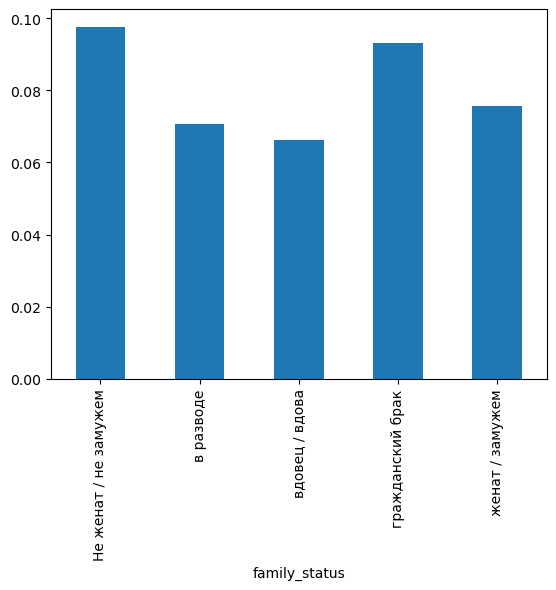

In [29]:
family_types_fails = data.groupby('family_status')['debt'].agg('mean')
family_types_fails.plot.bar()


Количество строк в категориях сопоставимо, и есть явные различия между категориями. Видно, что столкновение с браком (2, 3 и 5-ый столбцы графика) существенно увеличивает финансовую сознательность - люди, без пары или в гражданском браке существенно больше любят просрочку кредита, чем уже впавшие в семейную жизнь. Не женаты - самая рисковая категория, чем же дольше в браке, тем меньше вероятность задолженности.

**Вывод: Да, зависимость между типом семейного состояния явно есть, и чем больше человек жил в браке, тем меньше вероятность просрочки, самые рисковые - неженатые (9,8% вероятность просрочки кредита), а успешно пережившие брак - от женатых (7,5% вероятность просрочки) вплоть до развода (7,0% вероятность просрочки) или вдовцов (6,6%) - самые безрисковые категории.** 

<a id='question3'></a>
#### Есть ли зависимость между уровнем дохода и возвратом кредита в срок?

Посмотрим вероятности в зависимости от принадлежности к разным группам доходов:

,total_clients,total_failed_debts,probability_of_failed_debt
total_income_category,,,
A,25,2,0.080000
B,5014,354,0.070602
C,15921,1353,0.084982
D,349,21,0.060172
E,22,2,0.090909


'Средняя вероятность в целом на выборке:'

'0.0812'

<Axes: xlabel='total_income_category'>

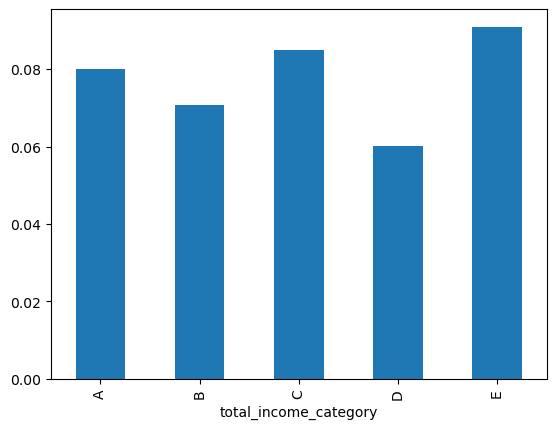

In [30]:
# Выводим сводную таблицу с количеством клиентов, количеством просрочек и их средней величиной:
data_pivot= data.pivot_table(index=['total_income_category'], values='debt', aggfunc='count')
data_pivot['total_failed_debts'] = data.pivot_table(index=['total_income_category'], values='debt', aggfunc='sum')
data_pivot['probability_of_failed_debt'] = data.pivot_table(index=['total_income_category'], values='debt', aggfunc='mean')
data_pivot = data_pivot.rename(columns={'debt': 'total_clients'})
display(data_pivot)

display('Средняя вероятность в целом на выборке:', "{0:.4f}".format(data['debt'].mean()))

# Выводим график вероятности в зависимости от категории дохода:
data_money_suspect = data.groupby('total_income_category')['debt'].agg('mean')
data_money_suspect.plot.bar()


Не обнаруживается существенной глобальной зависимости от дохода. Единственное, что выбивается - самые бедные чаще допускают
просрочку по кредиту, что кажется интуитивно понятным выводом. В других категориях существенной зависимости на глаз нет.
Проверим, не статвыброс ли в бедных из-за малого числа данных - посмотрев еще раз в столбец total clients сводной таблицы:

In [31]:
data_pivot= data.pivot_table(index=['total_income_category'], values='debt', aggfunc='count')
display(data_pivot)

,debt
total_income_category,
A,25
B,5014
C,15921
D,349
E,22


Малое число данных не позволяет сделать надежных выводов. Итого, зависимости не наблюдается с текущими инструментами.

Если сосредоточитстся на категориях, гда данных достаточно - B и C - то, мы видим зависимость - чем больше зароботок, тем меньше вероятность просрочки кредита, примерно на 1,4% меньше шансов допустить просрочку у людей с зарплатами от 200 тысяч до 1 млн р, в сравнении с получающими меньше 200 т.р. Это интуитивно ожидаемый результат.

**Вывод: Если исключить категории самых бедных и самых богатых, оставив основыне категории с запрлатами от 50 до 200 т.р. и от 200 т.р. до 1 млн р., то более богатые клиенты в среднем допускают просрочку на 1,4% реже в сравнении с бедными. Низшие и высшие страты доходов не оценить из-за небольшого числа данных.** 

<a id='question4'></a>
#### Как разные цели кредита влияют на его возврат в срок?

,total_clients,total_failed_debts,probability_of_failed_debt
purpose_category,,,
операции с автомобилем,4279,400,0.093480
операции с недвижимостью,10751,780,0.072551
получение образования,3988,369,0.092528
проведение свадьбы,2313,183,0.079118


'Средняя вероятность в целом на выборке:'

'0.0812'

<Axes: xlabel='purpose_category'>

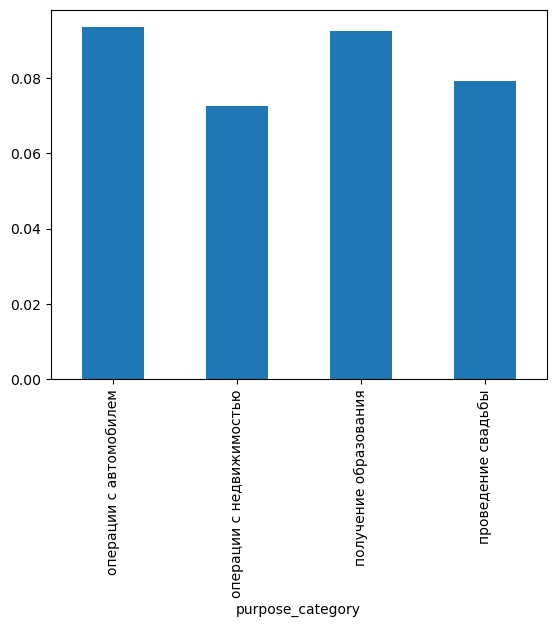

In [32]:
# Выводим сводную таблицу с количеством клиентов, количеством просрочек и их средней величиной:
data_pivot= data.pivot_table(index=['purpose_category'], values='debt', aggfunc='count')
data_pivot['total_failed_debts'] = data.pivot_table(index=['purpose_category'], values='debt', aggfunc='sum')
data_pivot['probability_of_failed_debt'] = data.pivot_table(index=['purpose_category'], values='debt', aggfunc='mean')
data_pivot = data_pivot.rename(columns={'debt': 'total_clients'})
display(data_pivot)

# Вычисляем средние по категориям и сравниваем со средим на выборке.
display('Средняя вероятность в целом на выборке:', "{0:.4f}".format(data['debt'].mean()))

# Строим график средних вероятностей просрочки:
data_but_why_suspect = data.groupby('purpose_category')['debt'].agg('mean')
data_but_why_suspect.plot.bar()

Выборки сопоставимы. Операции с недвижимость выбиваются как наименее подверженные риску просрочки - что логично ожидать, так как это серьезное решение. Более легковестные решения чаще подвержены риску просрочки - машины и образование. Кредиты на свадьбу - не отклоняется от среднего по выборке, что удивительно. Скорее всего, мы видим корреляцию с браком, которая, как мы видели выше, существенно снижает риск просрочки. 

**Вывод: менее существенные причины взятия кредита - более рисковы с точки зрения просрочки. Наименнее рисковым является, из-за высокой цены ошибки и внешнего контроля, - недвижимость (7,2% вероятность просрочки). Машины (9,3%) и образование (9,2%) значимо более рисковы - скорее всего, есть корреляция с переменной брака и поэтому снижение риска просрочки. Кредиты на свадьбу в целом не отклоняются от среднего риска просрочки по выборке.** 

#### Приведите возможные причины появления пропусков в исходных данных.

*Ответ: человеческие ошибки при вводе, ошибки выгрузки из данных, в случае этого набора данных - скорее всего, нежелание людей заполнять данные в анкетировании или вводе личных данных.* 

#### Объясните, почему заполнить пропуски медианным значением — лучшее решение для количественных переменных.

*Ответ: Обычно заполняют либо медианой, либо средним значением. Медиана будет меньше искажать распределение после заполнения пропусков, а среднее будет сдвигать его в сторону больших значений.* 

<a id='outro'></a>
### Общие выводы

**По результатам исследования, наиболее заметные влияния на риск просрочки кредита оказывают:**

1. **Наличие или отсутствие детей** - если дети есть, то вероятность просрочки значимо возрастает (7,5% вероятность просрочки без детей против 9,2% с детьми). Логично предположить, что траты на детей более приоритетны в сравнении с кредитом.

2. **Чем больше у человека опыта в браке, там ниже риск возникновения просрочки**, что ясно и из здравого смысла - брак вынуждает более отвественно подходить к финансам и рискам. Категории, имеющие больше опыта в браке - женатые (7,5 риска просрочки), вдовцы (6,6%) и разведенные (7%) существенно отличаются от неженатых (9,7% рсика просрочки) или состоящих в гражданском браке (9,3%). Т.е. состояние, прошлое или текущее в браке является значимой актуарной величиной, понижающей риски просрочки кредита.

3. **Зависимость вероятности просрочки от примерной дохода человека** можно описать только для самых больших, хорошо представленных в данных категориях заемщиков - с запрлатами от 50 до 200 т.р. и от 200 т.р. до 1 млн р. Среди этих двух, **более богатые несут меньший риск просрочки** (7% против 8,5% у бедных). Более бедные и более богатые категории клиетов сложно оценить из-за малого числа данных. 

4. Более тяжеловесные **кредиты на недвижимость несут существенно меньший риск просрочки (7,2%), чем остальные** (8,1% в среднем) - вероятно, из-за высокой цены невыплаты. Особенно более рисковы кредиты на машину (9,3% риска просрочки) и образование (9,2%)


Примечание: методы использованные в оценке - крайне примитивны (сравнения средних), это не в коем случае не андеррайтеровая модель.